# Import statements

In [1]:
import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
#import shap
from tensorflow.keras.models import load_model
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.activations import gelu
from tensorflow.keras.regularizers import l2

In [2]:
print(np.__version__)

1.26.3


In [3]:
print(np.__file__)

/home/supadhyaya/.local/lib/python3.10/site-packages/numpy/__init__.py


In [4]:
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load datasets

In [2]:
snp = pd.read_pickle("lasso_SNP_training_data.pkl")
snp.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [3]:
snp['Data-storage-ID'] = snp.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp = snp.reset_index(drop=True).set_index('Data-storage-ID')
snp.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [4]:
snp1 = snp.iloc[:, 0:244]
snp1.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,Gm20_38109920,Gm20_38319188,Gm20_43799361,Gm20_44581192,Gm20_44953155,Gm20_45338882,Gm20_47369848,Gm20_47648257,Gm20_49041864,Gm20_49612553
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,1,0,0,0,0,0,0,2
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,0,2,2,0,0,2,0,0,0
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,2,0,0,0,2,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,2,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,2,0,0,0,0,0,0


In [5]:
y1 = snp["seed_oil"]
y1.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [6]:
cov = snp.iloc[:,-34:]
cov.head()
## remove targte from this

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20.6
ESS,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20.9
ESS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,19.6


In [7]:
cov = cov.drop(columns=['seed_oil'])

In [8]:
cov.head()

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ESS,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ESS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
y_final = snp["seed_oil"]
y_final.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [10]:
pav = pd.read_pickle("gene_pav_LASSO_training_data.pkl")
pav.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,1,1,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [11]:
pav['Data-storage-ID'] = pav.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav = pav.reset_index(drop=True).set_index('Data-storage-ID')
pav.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,1,1,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [12]:
pav1 = pav.iloc[:, 0:154]
pav1.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,UWASoyPan04583,UWASoyPan04676,UWASoyPan04725,UWASoyPan04826,UWASoyPan04939,UWASoyPan04983,UWASoyPan05125,UWASoyPan05133,UWASoyPan05144,UWASoyPan05256
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,0,1,1,0,0,0,0,1,1,...,1,0,1,0,1,0,1,0,0,0
AB-02,1,1,1,0,1,1,1,1,1,1,...,1,1,0,0,1,0,0,0,0,1
BR-24,1,1,1,1,1,1,0,1,1,1,...,1,0,0,0,0,0,0,0,0,0
ESS,1,1,1,0,1,1,1,1,1,1,...,1,0,0,0,0,0,1,0,0,1
ESS,1,1,1,0,1,1,1,1,1,1,...,1,0,0,0,0,0,1,0,0,1


In [13]:
y2 = pav["seed_oil"]
y2.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [14]:
pfam = pd.read_pickle("pfam_pav_newIDs_eval5_varthreshold_lasso_training_data.pkl")
pfam.head()

,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [15]:
pfam['Data-storage-ID'] = pfam.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam = pfam.reset_index(drop=True).set_index('Data-storage-ID')
pfam.head()

,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [16]:
pfam1 = pfam.iloc[:, 0:104]
pfam1.head()

,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,PF04734_UWASoyPan03434,PF13456_UWASoyPan04184,PF16363_UWASoyPan04225,PF00393_UWASoyPan04254,PF00931_UWASoyPan04314,PF00764_UWASoyPan04505,PF13041_UWASoyPan04676,PF04572_UWASoyPan04901,PF00009_UWASoyPan04983,PF12481_UWASoyPan05039
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,0,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
AB-02,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,0,0
BR-24,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0


In [17]:
y3 = pfam["seed_oil"]
y3.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [18]:
X1 = snp1.values
X2 = pav1.values
X3 = pfam1.values
X4 = cov.values
y1 = y1.values
y2 = y2.values
y3 = y3.values
y_final = y_final.values

In [19]:
print(X1.shape, X2.shape, X3.shape, X4.shape)

(1144, 244) (1144, 154) (1144, 104) (1144, 33)


# Build model

In [20]:
#3 input model

num_features_1 = 244  
num_features_2 = 154
num_features_3 = 104 
# Input layers 
input_1 = Input(shape=(num_features_1,), name="input_1")
input_2 = Input(shape=(num_features_2,), name="input_2")
input_3 = Input(shape=(num_features_3,), name="input_3")

# Branch 1
x1 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)
branch_out1 = Dense(1, activation='linear', name="branch_output_1")(x1)  # intermediate output

# Branch 2 
x2 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_2)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)
x2 = Dense(64, activation='relu')(x2)
branch_out2 = Dense(1, activation='linear', name="branch_output_2")(x2)  # intermediate output

# Branch 3
x3 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_3)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.3)(x3)
x3 = Dense(64, activation='relu')(x3)
branch_out3 = Dense(1, activation='linear', name="branch_output_3")(x3)  # intermediate output

# Concatenate all branches
merged = Concatenate()([x1, x2, x3])

# Final combined layers
z = Dense(64, activation='relu')(merged)
z = BatchNormalization()(z)
z = Dropout(0.3)(z)
final_output = Dense(1, activation='linear', name="final_output")(z)

# Build the model
model = Model(
    inputs=[input_1, input_2, input_3],
    outputs=[branch_out1, branch_out2, branch_out3, final_output],
    name="multi_input_multi_output_model"
)

In [64]:
#4 input model

num_features_1 = 244  
num_features_2 = 154
num_features_3 = 104 
num_features_4 = 33
# Input layers 
input_1 = Input(shape=(num_features_1,), name="input_1")
input_2 = Input(shape=(num_features_2,), name="input_2")
input_3 = Input(shape=(num_features_3,), name="input_3")
input_4 = Input(shape=(num_features_4,), name="input_4")

# Branch 1
x1 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)
branch_out1 = Dense(1, activation='linear', name="branch_output_1")(x1)  # intermediate output

# Branch 2
x2 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_2)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)
x2 = Dense(64, activation='relu')(x2)
branch_out2 = Dense(1, activation='linear', name="branch_output_2")(x2)  # intermediate output

# Branch 3
x3 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_3)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.3)(x3)
x3 = Dense(64, activation='relu')(x3)
branch_out3 = Dense(1, activation='linear', name="branch_output_3")(x3)  # intermediate output

# Concatenate all branches
merged = Concatenate()([x1, x2, x3, input_4])


# Final combined layers
z = Dense(64, activation='relu')(merged)
z = BatchNormalization()(z)
z = Dropout(0.3)(z)
final_output = Dense(1, activation='linear', name="final_output")(z)

# Build the model
model = Model(
    inputs=[input_1, input_2, input_3, input_4],
    outputs=[branch_out1, branch_out2, branch_out3, final_output],
    name="multi_input_multi_output_model"
)

In [21]:
model.summary()

Model: "multi_input_multi_output_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 244)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 154)]                0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 104)]                0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  31360     ['input_1[0][0]']             
                                                                     

In [65]:

# --- Compile the model ---
model.compile(
    optimizer='adam',
    loss={
        "branch_output_1": "mse",
        "branch_output_2": "mse",
        "branch_output_3": "mse",
        "final_output": "mse"
    },
    metrics=['mae']
)

In [79]:
#DON'T DO THIS
model.compile(
    optimizer='adam',
    loss={
        'branch_output_1': 'mse',
        'branch_output_2': 'mse',
        'branch_output_3': 'mse',
        'final_output': 'mse'
    },
    loss_weights={
        'branch_output_1': 0.2,
        'branch_output_2': 0.2,
        'branch_output_3': 0.2,
        'final_output': 1.0
    },
      metrics={
        'branch_output_1': ['mae'],
        'branch_output_2': ['mae'],
        'branch_output_3': ['mae'],
        'final_output':   ['mae']
    }
)


In [23]:
for i, X in enumerate([X1, X2, X3, X4], start=1):
    print(f"X{i} dtype:", getattr(X, "dtype", "no dtype"))
    print(f"X{i} sample:", X[:2])

for i, y in enumerate([y1, y2, y3, y_final], start=1):
    print(f"y{i} dtype:", getattr(y, "dtype", "no dtype"))
    print(f"y{i} sample:", y[:5])

X1 dtype: int64
X1 sample: [[0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 2 0 0 0 1 2 0 2 0
  0 2 2 2 0 0 0 2 2 2 0 2 0 2 0 0 2 0 0 0 0 2 0 0 0 2 2 2 2 2 2 0 0 2 0 0
  0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 0 0 0 2 0 1 2 2 2 0 0 0 0 0
  2 0 0 1 0 2 1 0 0 0 2 2 0 0 0 0 2 0 2 2 0 0 2 2 0 2 0 0 2 0 0 0 0 2 2 0
  2 1 0 0 0 0 2 2 0 1 2 2 0 0 2 2 2 2 2 2 0 0 0 0 0 0 0 0 1 1 0 0 1 2 0 0
  0 2 2 0 2 2 2 0 2 2 0 0 0 0 0 1 0 0 2 0 0 2 0 0 0 2 2 2 2 0 0 1 2 2 0 2
  0 2 0 2 1 2 2 2 2 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 2]
 [2 0 0 0 2 2 2 0 0 0 0 2 0 0 0 2 2 0 0 2 2 0 0 0 0 0 2 2 2 0 0 1 2 0 0 2
  0 0 1 2 0 0 0 0 0 0 0 0 0 0 2 2 0 2 2 2 2 0 0 0 2 2 0 0 0 2 0 0 0 2 0 2
  2 0 0 0 2 0 2 0 0 0 2 0 0 0 0 0 2 0 0 2 2 0 2 2 0 2 0 0 0 2 2 0 2 0 0 1
  0 0 2 0 2 0 0 2 0 2 2 2 0 0 2 2 2 2 0 0 0 0 0 2 0 2 2 2 2 0 0 0 0 2 2 2
  0 2 0 0 0 0 0 0 2 0 0 0 0 2 0 0 2 2 2 2 0 2 0 2 2 2 2 2 2 1 2 0 0 0 0 0
  2 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 2 0 0 0 2 0 0 2 0 2 0 0 2 2 0 2 2 2
  0 0 2 0 2 0 0 0 0 0 2 0 

In [66]:
X1 = np.asarray(X1, dtype=np.float32)
X2 = np.asarray(X2, dtype=np.float32)
X3 = np.asarray(X3, dtype=np.float32)
X4 = np.asarray(X4, dtype=np.float32)

y1 = np.asarray(y1, dtype=np.float32)
y2 = np.asarray(y2, dtype=np.float32)
y3 = np.asarray(y3, dtype=np.float32)
y_final = np.asarray(y_final, dtype=np.float32)

In [67]:
# training all models

In [80]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',    # Stop based on validation loss
    patience=10,           # Wait 10 epochs for improvement
    restore_best_weights=True  # Restore weights from the best epoch
)

In [81]:
# Model checkpoint callback
checkpoint = ModelCheckpoint(
    "best_model_LASSO_withenv_weight.h5",       # Filepath to save the model
    monitor='val_loss',    # Save based on validation loss
    save_best_only=True,   # Only save the best model
    save_weights_only=False  # Save the entire model (architecture + weights)
)

In [164]:
#Not required
lr_reduction = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=10
    )

In [30]:
tf.config.experimental_run_functions_eagerly(True)

Instructions for updating:
Use `tf.config.run_functions_eagerly` instead of the experimental version.


In [82]:
history = model.fit( [X1, X2, X3, X4], [y1, y2, y3, y_final], 
                     epochs=100, batch_size=32, validation_split=0.1, verbose=0, 
                   callbacks=[early_stop, checkpoint])

/usr/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
/usr/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [167]:
#history = model.fit( [X1, X2, X3, X4], [y1, y2, y3, y_final], 
                     epochs=100, batch_size=32, validation_split=0.2, verbose=0,
                   callbacks=[early_stop, checkpoint, lr_reduction])

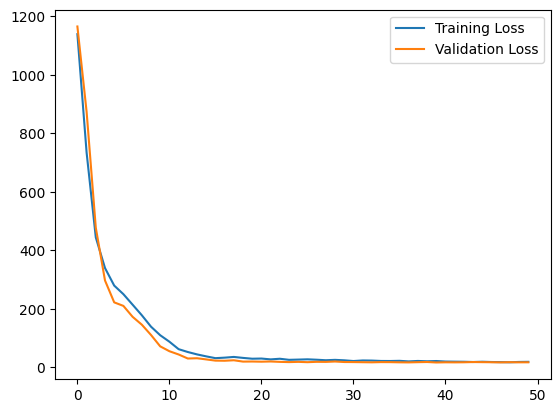

In [72]:
#for new model
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.savefig("loss_curve_so_lasso_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

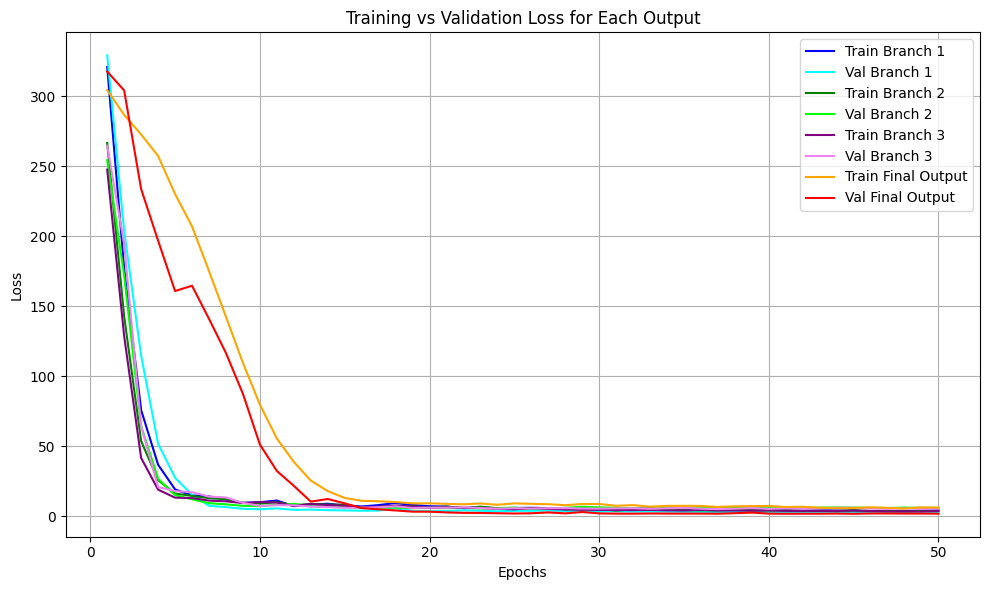

In [73]:

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10, 6))

# Branch 1
plt.plot(epochs, history.history['branch_output_1_loss'], label='Train Branch 1', color='blue')
plt.plot(epochs, history.history['val_branch_output_1_loss'], label='Val Branch 1', color='cyan')

# Branch 2
plt.plot(epochs, history.history['branch_output_2_loss'], label='Train Branch 2', color='green')
plt.plot(epochs, history.history['val_branch_output_2_loss'], label='Val Branch 2', color='lime')

# Branch 3
plt.plot(epochs, history.history['branch_output_3_loss'], label='Train Branch 3', color='purple')
plt.plot(epochs, history.history['val_branch_output_3_loss'], label='Val Branch 3', color='violet')

# Final Output
plt.plot(epochs, history.history['final_output_loss'], label='Train Final Output', color='orange')
plt.plot(epochs, history.history['val_final_output_loss'], label='Val Final Output', color='red')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss for Each Output')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("perbranch_curve_so_lasso_withenv.png", dpi=600, bbox_inches="tight")
plt.show()


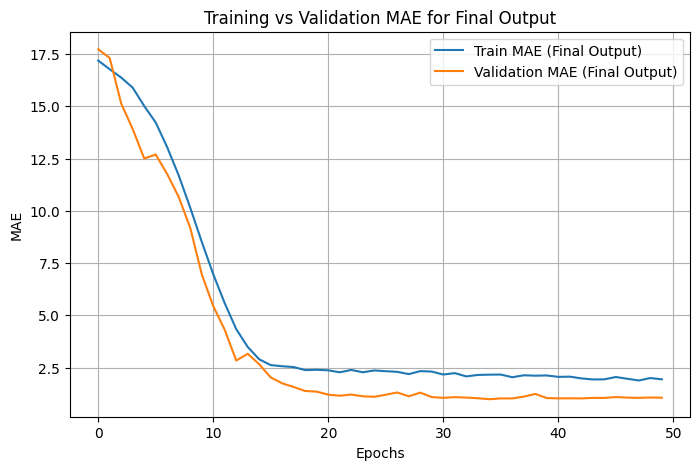

In [74]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['final_output_mae'], label='Train MAE (Final Output)')
plt.plot(history.history['val_final_output_mae'], label='Validation MAE (Final Output)')

plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE for Final Output')
plt.legend()
plt.grid(True)
plt.show()

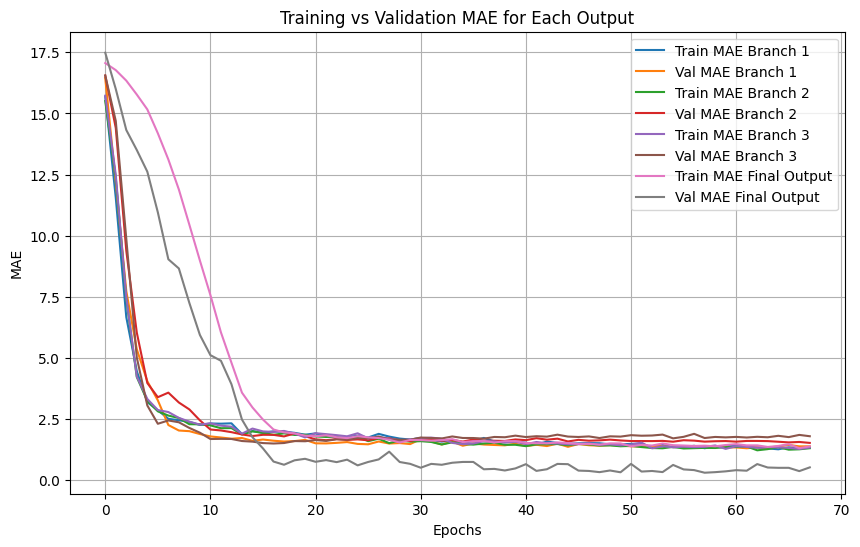

In [73]:
plt.figure(figsize=(10, 6))

# Branch 1
plt.plot(history.history['branch_output_1_mae'], label='Train MAE Branch 1')
plt.plot(history.history['val_branch_output_1_mae'], label='Val MAE Branch 1')

# Branch 2
plt.plot(history.history['branch_output_2_mae'], label='Train MAE Branch 2')
plt.plot(history.history['val_branch_output_2_mae'], label='Val MAE Branch 2')

# Branch 3
plt.plot(history.history['branch_output_3_mae'], label='Train MAE Branch 3')
plt.plot(history.history['val_branch_output_3_mae'], label='Val MAE Branch 3')

# Final Output
plt.plot(history.history['final_output_mae'], label='Train MAE Final Output')
plt.plot(history.history['val_final_output_mae'], label='Val MAE Final Output')

plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE for Each Output')
plt.legend()
plt.grid(True)
plt.show()

# Testing

In [38]:
holdout = pd.read_pickle("snp_pav_pfam_holdout_afterLASSO.pkl")

In [39]:
holdout.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,15.6


In [40]:
snp_holdout = holdout[snp1.columns]

In [41]:
snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp_holdout = snp_holdout.reset_index(drop=True).set_index('Data-storage-ID')
snp_holdout.head()

/tmp/ipykernel_2472797/3552470459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]


,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,Gm20_38109920,Gm20_38319188,Gm20_43799361,Gm20_44581192,Gm20_44953155,Gm20_45338882,Gm20_47369848,Gm20_47648257,Gm20_49041864,Gm20_49612553
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,1,0,0,0,2,2,...,0,0,0,2,2,0,0,2,0,0
HN010,0,0,0,2,2,2,2,0,2,2,...,0,0,0,0,2,2,0,2,2,2
HN015,2,0,0,0,2,2,2,0,2,2,...,0,2,0,0,2,2,0,2,0,0
HN017B,0,0,0,2,2,2,2,0,2,2,...,2,0,0,0,2,2,0,0,0,0
HN023,2,0,0,0,2,0,2,0,2,2,...,0,0,0,2,2,0,0,0,2,0


In [42]:
snp_holdout.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,Gm20_38109920,Gm20_38319188,Gm20_43799361,Gm20_44581192,Gm20_44953155,Gm20_45338882,Gm20_47369848,Gm20_47648257,Gm20_49041864,Gm20_49612553
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,1,0,0,0,2,2,...,0,0,0,2,2,0,0,2,0,0
HN010,0,0,0,2,2,2,2,0,2,2,...,0,0,0,0,2,2,0,2,2,2
HN015,2,0,0,0,2,2,2,0,2,2,...,0,2,0,0,2,2,0,2,0,0
HN017B,0,0,0,2,2,2,2,0,2,2,...,2,0,0,0,2,2,0,0,0,0
HN023,2,0,0,0,2,0,2,0,2,2,...,0,0,0,2,2,0,0,0,2,0


In [43]:
pav_holdout = holdout[pav1.columns]

In [44]:
pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav_holdout = pav_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pav_holdout.head()

/tmp/ipykernel_2472797/2899270742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]


,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,UWASoyPan04583,UWASoyPan04676,UWASoyPan04725,UWASoyPan04826,UWASoyPan04939,UWASoyPan04983,UWASoyPan05125,UWASoyPan05133,UWASoyPan05144,UWASoyPan05256
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,0,1,1,1,1,1,1,1,...,0,0,1,0,0,1,0,0,0,1
HN010,1,1,1,0,0,1,0,1,1,1,...,0,1,1,0,1,0,0,0,0,1
HN015,0,1,1,0,1,1,0,1,1,0,...,1,0,1,0,1,1,0,0,0,1
HN017B,0,0,1,0,1,1,0,1,1,0,...,1,0,1,0,1,1,1,0,0,0
HN023,1,0,1,0,1,0,1,1,1,1,...,1,1,0,0,0,0,1,0,0,0


In [45]:
pav_holdout.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,UWASoyPan04583,UWASoyPan04676,UWASoyPan04725,UWASoyPan04826,UWASoyPan04939,UWASoyPan04983,UWASoyPan05125,UWASoyPan05133,UWASoyPan05144,UWASoyPan05256
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,0,1,1,1,1,1,1,1,...,0,0,1,0,0,1,0,0,0,1
HN010,1,1,1,0,0,1,0,1,1,1,...,0,1,1,0,1,0,0,0,0,1
HN015,0,1,1,0,1,1,0,1,1,0,...,1,0,1,0,1,1,0,0,0,1
HN017B,0,0,1,0,1,1,0,1,1,0,...,1,0,1,0,1,1,1,0,0,0
HN023,1,0,1,0,1,0,1,1,1,1,...,1,1,0,0,0,0,1,0,0,0


In [46]:
pfam_holdout = holdout[pfam1.columns]

In [47]:
pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam_holdout = pfam_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pfam_holdout.head()

/tmp/ipykernel_2472797/577540637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]


,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,PF04734_UWASoyPan03434,PF13456_UWASoyPan04184,PF16363_UWASoyPan04225,PF00393_UWASoyPan04254,PF00931_UWASoyPan04314,PF00764_UWASoyPan04505,PF13041_UWASoyPan04676,PF04572_UWASoyPan04901,PF00009_UWASoyPan04983,PF12481_UWASoyPan05039
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,1,0
HN010,0,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,1,0,0,0
HN015,1,0,1,1,1,0,1,1,1,0,...,0,0,0,1,0,0,0,0,1,0
HN017B,1,0,1,1,1,0,1,1,1,1,...,0,0,0,0,1,0,0,0,1,0
HN023,1,1,1,0,0,0,0,1,1,1,...,0,0,1,0,0,0,1,0,0,0


In [48]:
pfam_holdout.head()

,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,PF04734_UWASoyPan03434,PF13456_UWASoyPan04184,PF16363_UWASoyPan04225,PF00393_UWASoyPan04254,PF00931_UWASoyPan04314,PF00764_UWASoyPan04505,PF13041_UWASoyPan04676,PF04572_UWASoyPan04901,PF00009_UWASoyPan04983,PF12481_UWASoyPan05039
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,1,0
HN010,0,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,1,0,0,0
HN015,1,0,1,1,1,0,1,1,1,0,...,0,0,0,1,0,0,0,0,1,0
HN017B,1,0,1,1,1,0,1,1,1,1,...,0,0,0,0,1,0,0,0,1,0
HN023,1,1,1,0,0,0,0,1,1,1,...,0,0,1,0,0,0,1,0,0,0


In [49]:
cov_holdout = holdout[cov.columns]

In [50]:
cov_holdout.head()

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN015_SOYBEAN.EVALUATION.3IL83.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B_SOYBEAN.EVALUATION.3IL83.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN023_SOYBEAN.EVALUATION.2IL81.2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
cov_holdout = cov_holdout.reset_index(drop=True).set_index('Data-storage-ID')
cov_holdout.head()

/tmp/ipykernel_2472797/403245011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]


,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN023,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
y1_test = holdout['seed_oil'].values
y2_test = holdout['seed_oil'].values
y3_test = holdout['seed_oil'].values
y_final_test = holdout['seed_oil'].values

In [53]:
y1_test

array([16.8, 18.3, 15. , 15.5, 15.6, 18.1,  6.5, 14.3, 11.7,  9.9, 17.3,
       19.8, 16.2, 16.5, 16.5, 20.3, 18.7, 17.8, 17.2, 18.9, 20.5, 11. ,
       11.5, 14.9, 17.3,  9. , 18.9, 20.1,  8.8, 11.7, 10.7, 12.1, 11.8,
       11.4,  9.6, 11.7, 10.9, 11.1, 10.6, 11.3,  9.6, 10.6, 10.9,  7.2,
       20.9, 19.1, 19.4, 21.7, 21.4, 21.7, 22.4, 18.9, 18.3,  6.8, 17.2,
       19.1, 17.8, 21. , 20.4, 19. , 20.6, 20.2, 19. , 21.6, 18.4, 12.7,
       14.7, 18.5, 15.9, 20.8, 17.6, 19.4, 17.9, 20.5, 20.3, 18.4, 15.7,
       15. , 17.5, 20.8, 21.2, 18.3, 20.9, 18.5, 19.6, 18.5, 17.3, 16.7,
       16.2, 17.8, 19.6, 15.7, 20.4, 18. , 18.1, 15.9, 15.8, 19.9, 19.5,
       20. , 20.3, 16.8, 20. , 19.2, 18.9, 21.6, 18.2, 16. , 12.6, 20.8,
       18. , 19.5, 20.7, 20. , 19.8, 19.3, 17.9, 17.2, 17.1, 17.9, 18.9,
       20.7, 18. , 15.1, 17.7, 18.7, 14.8, 16.2])

In [54]:
X1_test = snp_holdout.values
X2_test = pav_holdout.values
X3_test = pfam_holdout.values
X4_test = cov_holdout.values

In [85]:
model = load_model('best_model_LASSO_withenv.h5')

In [55]:
model.summary()

Model: "multi_input_multi_output_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 244)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 154)]                0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 104)]                0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  31360     ['input_1[0][0]']             
                                                                     

In [39]:
print(X1_test.dtype, X2_test.dtype, X3_test.dtype, X4_test.dtype)

int64 object int64 int64


In [56]:
X1_test = X1_test.astype("float32")
X2_test = X2_test.astype("float32")
X3_test = X3_test.astype("float32")
X4_test = X4_test.astype("float32")

In [57]:
print(X1_test.shape)
print(X2_test.shape)
print(X3_test.shape)
print(X4_test.shape)

(128, 244)
(128, 154)
(128, 104)
(128, 33)


In [76]:
pred1, pred2, pred3, pred_final = model.predict(
    [X1_test, X2_test, X3_test, X4_test]
)

4/4 [==============================] - 0s 10ms/step


In [77]:
results = model.evaluate(
    [X1_test, X2_test, X3_test, X4_test],
    [y1_test, y2_test, y3_test, y_final_test],
    verbose=1
)

print(results)

4/4 [==============================] - 0s 30ms/step - loss: 13.7887 - branch_output_1_loss: 3.9648 - branch_output_2_loss: 4.1580 - branch_output_3_loss: 3.7957 - final_output_loss: 1.8657 - branch_output_1_mae: 1.4455 - branch_output_2_mae: 1.5847 - branch_output_3_mae: 1.5423 - final_output_mae: 1.0302
[13.788739204406738, 3.964796543121338, 4.1580305099487305, 3.79571533203125, 1.8656611442565918, 1.4455037117004395, 1.5846757888793945, 1.5423362255096436, 1.0301579236984253]


In [86]:
# RMSE
rmse_1 = np.sqrt(mean_squared_error(y1_test, pred1))
rmse_2 = np.sqrt(mean_squared_error(y2_test, pred2))
rmse_3 = np.sqrt(mean_squared_error(y3_test, pred3))
rmse_final = np.sqrt(mean_squared_error(y_final_test, pred_final))

# R²
r2_1 = r2_score(y1_test, pred1)
r2_2 = r2_score(y2_test, pred2)
r2_3 = r2_score(y3_test, pred3)
r2_final = r2_score(y_final_test, pred_final)

#Pearson r
pearson_1, pval_1 = pearsonr(y1_test.flatten(), pred1.flatten())
pearson_2, pval_2 = pearsonr(y2_test.flatten(), pred2.flatten())
pearson_3, pval_3 = pearsonr(y3_test.flatten(), pred3.flatten())
pearson_final, pval_final = pearsonr(y_final_test.flatten(), pred_final.flatten())

# preint metrics
print("\n===== PERFORMANCE METRICS =====")
print(f"Branch 1 – RMSE: {rmse_1:.4f}, R²: {r2_1:.4f}, Pearson r: {pearson_1:.4f} (p={pval_1:.2e})")
print(f"Branch 2 – RMSE: {rmse_2:.4f}, R²: {r2_2:.4f}, Pearson r: {pearson_2:.4f} (p={pval_2:.2e})")
print(f"Branch 3 – RMSE: {rmse_3:.4f}, R²: {r2_3:.4f}, Pearson r: {pearson_3:.4f} (p={pval_3:.2e})")
print(f"Final Output – RMSE: {rmse_final:.4f}, R²: {r2_final:.4f}, Pearson r: {pearson_final:.4f} (p={pval_final:.2e})")


===== PERFORMANCE METRICS =====
Branch 1 – RMSE: 1.9912, R²: 0.7073, Pearson r: 0.8476 (p=1.79e-36)
Branch 2 – RMSE: 2.0391, R²: 0.6930, Pearson r: 0.8339 (p=2.56e-34)
Branch 3 – RMSE: 1.9483, R²: 0.7198, Pearson r: 0.8500 (p=7.10e-37)
Final Output – RMSE: 1.3659, R²: 0.8623, Pearson r: 0.9298 (p=1.60e-56)


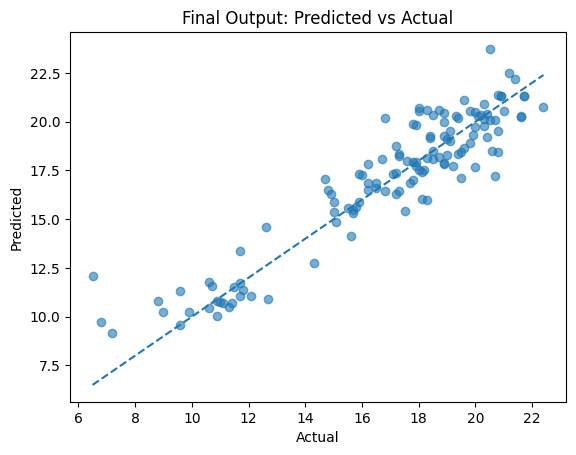

In [87]:
plt.scatter(y_final_test, pred_final, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Final Output: Predicted vs Actual")
plt.plot([y_final_test.min(), y_final_test.max()],
         [y_final_test.min(), y_final_test.max()],
         linestyle="--")   # 1:1 line
plt.savefig("predicted_actual_so_lasso_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

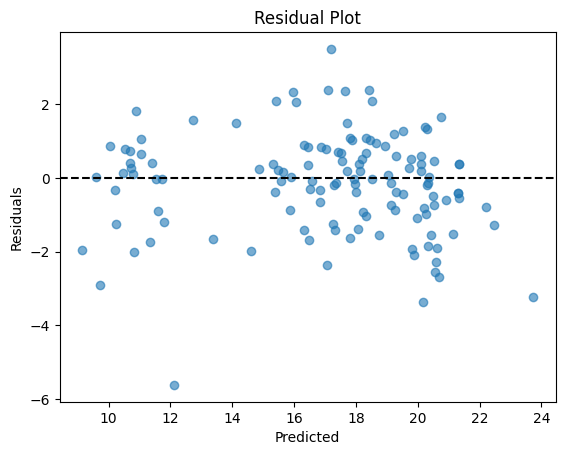

In [88]:
residuals = y_final_test - pred_final.reshape(-1)

plt.scatter(pred_final, residuals, alpha=0.6)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("residual_so_lasso_withenv.png", dpi=600, bbox_inches="tight")
plt.show()